# AI-Based Forest Fire & Smoke Detection Using Aerial Imagery

This notebook implements a supervised machine learning pipeline to detect forest fire and smoke regions from aerial-imagery-derived features. The goal is to evaluate model reliability and interpret spatial fire risk for drone-based disaster monitoring.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv("/datalab/Forest Fire Smoke Dataset - Sheet1 (1).csv")

In [ ]:
df.info

<bound method DataFrame.info of       mean_red  mean_green  mean_blue  red_blue_ratio  intensity_std  \
0     0.523653    0.299277   0.265874        1.962171       0.068402   
1     0.724041    0.394328   0.453850        1.591822       0.290540   
2     0.732028    0.492876   0.555428        1.315584       0.264537   
3     0.589471    0.527046   0.536978        1.095716       0.136997   
4     0.385249    0.669345   0.473443        0.812004       0.262034   
...        ...         ...        ...             ...            ...   
2995  0.850983    0.404330   0.375418        2.260739       0.195440   
2996  0.404829    0.422685   0.331614        1.217114       0.075921   
2997  0.487928    0.584428   0.217449        2.233604       0.096826   
2998  0.520066    0.588450   0.505704        1.026370       0.130731   
2999  0.654084    0.475203   0.330417        1.973597       0.214846   

      edge_density  smoke_whiteness  haze_index  hot_pixel_fraction  \
0         0.223412         0.472959    0.333490            0.158385   
1         0.345590         0.384785    0.404510            0.222511   
2         0.330369         0.705461    0.625930            0.359686   
3         0.458620         0.361735    0.367842            0.073597   
4         0.295832         0.294756    0.702075            0.221406   
...            ...              ...         ...                 ...   
2995      0.342355         0.472979    0.232336            0.651162   
2996      0.218798         0.470671    0.635284            0.019928   
2997      0.234187         0.275879    0.341900            0.070771   
2998      0.238155         0.225361    0.510601            0.045165   
2999      0.279030         0.542118    0.431166            0.555210   

      local_contrast  fire_label  
0           0.524992           0  
1           0.100019           1  
2           0.701875           1  
3           0.777261           0  
4           0.610500           0  
...              ...         ...  
2995        0.343191           1  
2996        0.413578           0  
2997        0.489887           0  
2998        0.341439           0  
2999        0.518189           1  

[3000 rows x 11 columns]>

In [ ]:
df.describe

<bound method NDFrame.describe of       mean_red  mean_green  mean_blue  red_blue_ratio  intensity_std  \
0     0.523653    0.299277   0.265874        1.962171       0.068402   
1     0.724041    0.394328   0.453850        1.591822       0.290540   
2     0.732028    0.492876   0.555428        1.315584       0.264537   
3     0.589471    0.527046   0.536978        1.095716       0.136997   
4     0.385249    0.669345   0.473443        0.812004       0.262034   
...        ...         ...        ...             ...            ...   
2995  0.850983    0.404330   0.375418        2.260739       0.195440   
2996  0.404829    0.422685   0.331614        1.217114       0.075921   
2997  0.487928    0.584428   0.217449        2.233604       0.096826   
2998  0.520066    0.588450   0.505704        1.026370       0.130731   
2999  0.654084    0.475203   0.330417        1.973597       0.214846   

      edge_density  smoke_whiteness  haze_index  hot_pixel_fraction  \
0         0.223412         0.472959    0.333490            0.158385   
1         0.345590         0.384785    0.404510            0.222511   
2         0.330369         0.705461    0.625930            0.359686   
3         0.458620         0.361735    0.367842            0.073597   
4         0.295832         0.294756    0.702075            0.221406   
...            ...              ...         ...                 ...   
2995      0.342355         0.472979    0.232336            0.651162   
2996      0.218798         0.470671    0.635284            0.019928   
2997      0.234187         0.275879    0.341900            0.070771   
2998      0.238155         0.225361    0.510601            0.045165   
2999      0.279030         0.542118    0.431166            0.555210   

      local_contrast  fire_label  
0           0.524992           0  
1           0.100019           1  
2           0.701875           1  
3           0.777261           0  
4           0.610500           0  
...              ...         ...  
2995        0.343191           1  
2996        0.413578           0  
2997        0.489887           0  
2998        0.341439           0  
2999        0.518189           1  

[3000 rows x 11 columns]>

In [ ]:
df.columns

Index(['mean_red', 'mean_green', 'mean_blue', 'red_blue_ratio',
       'intensity_std', 'edge_density', 'smoke_whiteness', 'haze_index',
       'hot_pixel_fraction', 'local_contrast', 'fire_label'],
      dtype='object')

In [ ]:
df.head()

,mean_red,mean_green,mean_blue,red_blue_ratio,intensity_std,edge_density,smoke_whiteness,haze_index,hot_pixel_fraction,local_contrast,fire_label
0,0.523653,0.299277,0.265874,1.962171,0.068402,0.223412,0.472959,0.333490,0.158385,0.524992,0
1,0.724041,0.394328,0.453850,1.591822,0.290540,0.345590,0.384785,0.404510,0.222511,0.100019,1
2,0.732028,0.492876,0.555428,1.315584,0.264537,0.330369,0.705461,0.625930,0.359686,0.701875,1
3,0.589471,0.527046,0.536978,1.095716,0.136997,0.458620,0.361735,0.367842,0.073597,0.777261,0
4,0.385249,0.669345,0.473443,0.812004,0.262034,0.295832,0.294756,0.702075,0.221406,0.610500,0


## Dataset Description

The dataset consists of tile-level features extracted from aerial imagery for forest fire and smoke detection.
Each row represents a spatial tile, and the features capture color, texture, intensity, and haze-related
properties that are indicative of fire or smoke presence.

The target variable `fire_label` indicates whether fire or smoke is present (1) or absent (0).


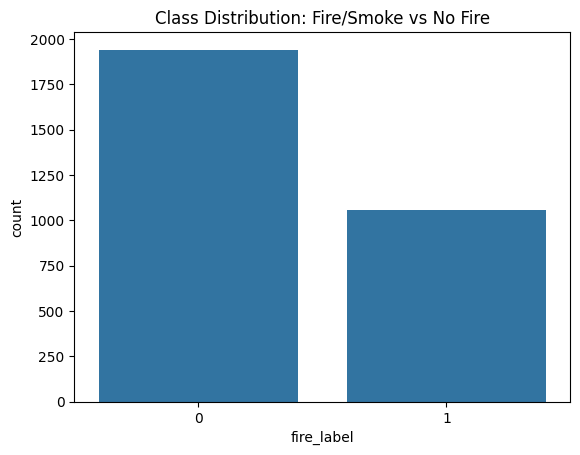

In [ ]:
sns.countplot(x='fire_label', data=df)
plt.title("Class Distribution: Fire/Smoke vs No Fire")
plt.show()


The class distribution shows the proportion of fire/smoke and non-fire regions.
This helps in understanding dataset balance and choosing appropriate evaluation metrics.


In [ ]:
df.columns

Index(['mean_red', 'mean_green', 'mean_blue', 'red_blue_ratio',
       'intensity_std', 'edge_density', 'smoke_whiteness', 'haze_index',
       'hot_pixel_fraction', 'local_contrast', 'fire_label'],
      dtype='object')

In [ ]:
target='fire_label'

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
y=df[target]

In [ ]:
x=df.drop(columns=[target])

In [ ]:
x

,mean_red,mean_green,mean_blue,red_blue_ratio,intensity_std,edge_density,smoke_whiteness,haze_index,hot_pixel_fraction,local_contrast
0,0.523653,0.299277,0.265874,1.962171,0.068402,0.223412,0.472959,0.333490,0.158385,0.524992
1,0.724041,0.394328,0.453850,1.591822,0.290540,0.345590,0.384785,0.404510,0.222511,0.100019
2,0.732028,0.492876,0.555428,1.315584,0.264537,0.330369,0.705461,0.625930,0.359686,0.701875
3,0.589471,0.527046,0.536978,1.095716,0.136997,0.458620,0.361735,0.367842,0.073597,0.777261
4,0.385249,0.669345,0.473443,0.812004,0.262034,0.295832,0.294756,0.702075,0.221406,0.610500
...,...,...,...,...,...,...,...,...,...,...
2995,0.850983,0.404330,0.375418,2.260739,0.195440,0.342355,0.472979,0.232336,0.651162,0.343191
2996,0.404829,0.422685,0.331614,1.217114,0.075921,0.218798,0.470671,0.635284,0.019928,0.413578
2997,0.487928,0.584428,0.217449,2.233604,0.096826,0.234187,0.275879,0.341900,0.070771,0.489887
2998,0.520066,0.588450,0.505704,1.026370,0.130731,0.238155,0.225361,0.510601,0.045165,0.341439


In [ ]:
y

,fire_label
0,0
1,1
2,1
3,0
4,0
...,...
2995,1
2996,0
2997,0
2998,0


In [ ]:
x_tr,x_te,y_tr,y_te=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model=RandomForestClassifier(n_estimators=100,random_state=42)

In [ ]:
model.fit(x_tr,y_tr)

RandomForestClassifier(random_state=42)

In [ ]:
model

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

y_pred = model.predict(x_te)
y_prob = model.predict_proba(x_te)[:,1]


In [ ]:
print(classification_report(y_te, y_pred))


              precision    recall  f1-score   support

           0       0.92      0.97      0.94       388
           1       0.94      0.84      0.89       212

    accuracy                           0.93       600
   macro avg       0.93      0.91      0.92       600
weighted avg       0.93      0.93      0.92       600



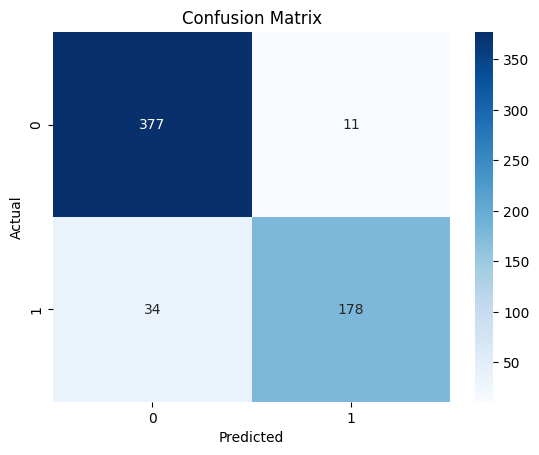

In [ ]:
cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


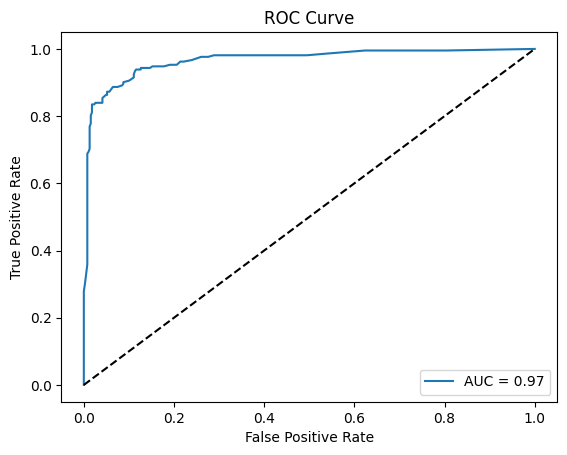

In [ ]:
roc_auc = roc_auc_score(y_te, y_prob)
fpr, tpr, _ = roc_curve(y_te, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## Model Performance Analysis

The Random Forest classifier demonstrates reliable performance in detecting fire and smoke regions.
Precision is particularly important in this context to reduce false alarms in disaster monitoring systems.
The ROC-AUC score indicates the model's ability to distinguish between fire and non-fire regions.


In [ ]:
df['fire_risk_score'] = model.predict_proba(x)[:,1]


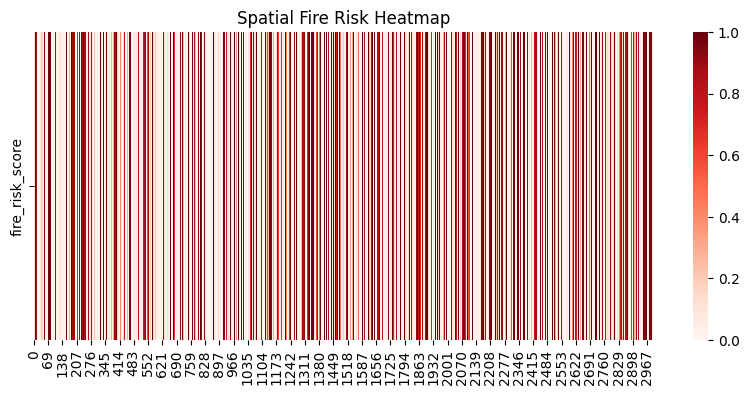

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10,4))
sns.heatmap(df[['fire_risk_score']].T, cmap='Reds')
plt.title("Spatial Fire Risk Heatmap")
plt.show()
plt.savefig("spatial_fire_risk_heatmap.png", bbox_inches="tight")


### Spatial Risk Interpretation

Each row in the dataset represents a spatial tile extracted from aerial imagery.
Although exact geographic coordinates are not provided, the predicted fire risk scores
can be interpreted as relative spatial risk levels across monitored regions.

In a real drone-based monitoring system, these risk scores would be mapped to geographic
locations, enabling emergency teams to prioritize high-risk areas for surveillance and response.


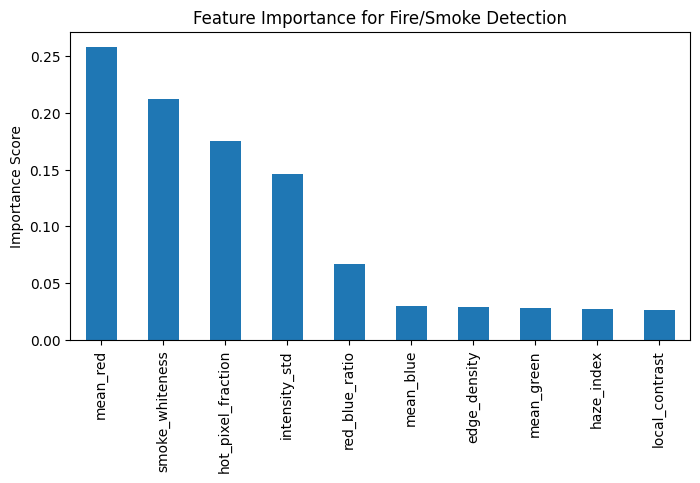

In [ ]:
importances = model.feature_importances_
feature_importance = pd.Series(importances, index=x.columns).sort_values(ascending=False)

plt.figure(figsize=(8,4))
feature_importance.plot(kind='bar')
plt.title("Feature Importance for Fire/Smoke Detection")
plt.ylabel("Importance Score")
plt.show()


### Feature Importance Analysis

The feature importance analysis highlights which visual characteristics contribute most
to fire and smoke detection. Features related to color intensity, haze, and hot pixel
distribution play a significant role, aligning with known visual indicators of forest fires.


## Drone-Based Disaster Response Interpretation

Regions with high predicted fire risk scores should be prioritized for drone surveillance.
Early detection allows emergency teams to respond before fires spread extensively.
AI-based risk maps enable efficient allocation of drones and firefighting resources.


## Limitations and Future Improvements

The dataset consists of pre-extracted features and does not include raw imagery or temporal data.
Future work could incorporate real-time video streams, thermal imagery, weather conditions,
and edge deployment on drones for continuous monitoring.


In [ ]:
plt.savefig("spatial_fire_risk_heatmap.png", bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

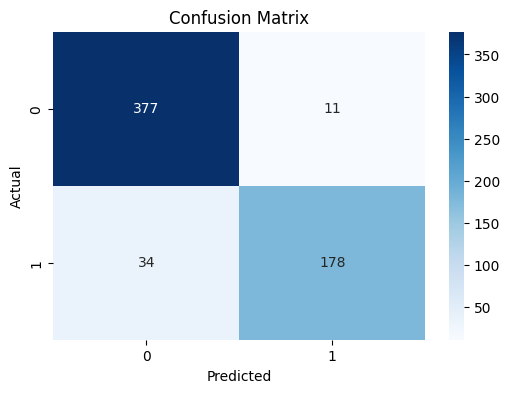

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_te, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("/content/confusion_matrix.png", bbox_inches="tight")
plt.show()


In [ ]:
text = """Model: Random Forest Classifier

Dataset: Aerial-imagery-derived tile-level features
Train-Test Split: 80-20 (stratified)

Accuracy: 93%
Precision (Fire): 94%
Recall (Fire): 84%
F1-score (Fire): 89%
ROC-AUC: 0.97
"""

file = open("/content/model_metrics.txt", "w")
file.write(text)
file.close()

print("model_metrics.txt created")


model_metrics.txt created


In [ ]:
!ls /content


confusion_matrix.png  sample_data
model_metrics.txt     spatial_fire_risk_heatmap.png


In [ ]:
from google.colab import files
files.download("/content/model_metrics.txt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
text = """AI-Based Forest Fire & Smoke Detection – Deliverables

This folder contains all required project deliverables apart from the Google Colab notebook.

Folder Contents:
1. visualizations/
   - spatial_fire_risk_heatmap.png
   - confusion_matrix.png
   - roc_curve.png
   - feature_importance.png

2. model_metrics.txt
   - Summary of model performance metrics

3. explanation_video_link.txt
   - Link to a short explanation video of the project

Project Description:
This project implements a supervised machine learning pipeline to detect forest fire and smoke regions
using aerial-imagery-derived tile-level features. The outputs include spatial risk visualizations,
model evaluation metrics, and interpretation for drone-based disaster monitoring.

The Google Colab notebook link is submitted separately.
"""

file = open("/content/README.txt", "w")
file.write(text)
file.close()

print("README.txt created")


README.txt created


In [ ]:
!ls /content


confusion_matrix.png  README.txt   spatial_fire_risk_heatmap.png
model_metrics.txt     sample_data


In [ ]:
from google.colab import files
files.download("/content/README.txt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>